In [1]:
import numpy as np
import pandas as pd
from random import seed, sample
from itertools import product
import joblib

from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams.update({'font.size': 10})

#### Import dataset

Synthesized sequences

In [2]:
synthesized = pd.read_csv('data/synthesized.csv')

#### Encode

Encode the sequences

In [3]:
def seq_fingerprint(sequence):
    fp = np.zeros(len(sequence))
    for i, char in enumerate(sequence):
        if char.isupper():
            fp[i] = 1
    return fp

synthesized['fingerprint'] = synthesized['sequence'].apply(seq_fingerprint)

#### Data Preprocessing: Activity

Input, labels and scrambled labels

In [4]:
seed(42)

X = np.array(synthesized['fingerprint'].tolist())
y = np.array(synthesized['active'].tolist())
y_scrambled = np.array(sample(list(y), len(y)))

#### Model Validation: Activity

Initialize the model

In [5]:
mlp = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Helper function

In [6]:
def evaluate_model(cv, mlp, X, y, plot_path='plots/model_eval.png', color='#648FFF'):

    aucs = []
    tprs = []
    base_fpr = np.linspace(0, 1, 101)

    accuracies = []
    precisions = []
    recalls = []
    f1s = []

    plt.figure(figsize=(3, 3))
    plt.axes().set_aspect('equal', 'datalim')

    for i, (train, test) in enumerate(cv.split(X, y)):
        mlp.fit(X[train], y[train])

        y_score = mlp.predict_proba(X[test])
        y_pred = mlp.predict(X[test])

        fpr, tpr, _ = roc_curve(y[test], y_score[:, 1])
        accuracies.append(accuracy_score(y[test], y_pred))
        precisions.append(precision_score(y[test], y_pred, zero_division=0))
        recalls.append(recall_score(y[test], y_pred, zero_division=0))
        f1s.append(f1_score(y[test], y_pred, zero_division=0))
        
        plt.plot(fpr, tpr, color, alpha=0.15)
        
        tpr = np.interp(base_fpr, fpr, tpr)
        tpr[0] = 0.0

        tprs.append(tpr)
        aucs.append(roc_auc_score(y[test], y_score[:, 1]))

    tprs = np.array(tprs)
    mean_tprs = tprs.mean(axis=0)
    std = tprs.std(axis=0)
    tprs_upper = np.minimum(mean_tprs + std, 1)
    tprs_lower = mean_tprs - std

    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    mean_precision = np.mean(precisions)
    std_precision = np.std(precisions)

    mean_recall = np.mean(recalls)
    std_recall = np.std(recalls)

    mean_f1 = np.mean(f1s)
    std_f1 = np.std(f1s)

    plt.plot(base_fpr, mean_tprs, color)
    plt.fill_between(base_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.15)

    plt.plot([0, 1], [0, 1],'k--', linewidth=1)
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.text(0.525, 0.05, f'Mean AUC: {round(np.mean(aucs), 2)}')
    plt.savefig(plot_path, dpi=1200, bbox_inches='tight')

    print(f'Mean accuracy: {round(mean_accuracy, 2)} ± {round(std_accuracy, 2)}')
    print(f'Mean precision: {round(mean_precision, 2)} ± {round(std_precision, 2)}')
    print(f'Mean recall: {round(mean_recall, 2)} ± {round(std_recall, 2)}')
    print(f'Mean F1: {round(mean_f1, 2)} ± {round(std_f1, 2)}')

Scrambled labels

Mean accuracy: 0.73 ± 0.07
Mean precision: 0.33 ± 0.29
Mean recall: 0.17 ± 0.13
Mean F1: 0.22 ± 0.18


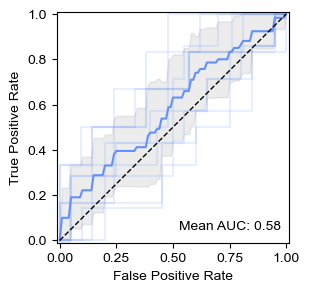

In [7]:
evaluate_model(cv, mlp, X, y_scrambled, plot_path='plots/mlp_act_scrambled.png')

True labels

Mean accuracy: 0.89 ± 0.06
Mean precision: 0.85 ± 0.15
Mean recall: 0.7 ± 0.21
Mean F1: 0.74 ± 0.15


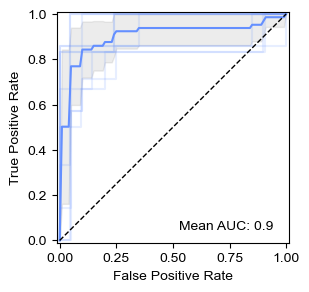

In [8]:
evaluate_model(cv, mlp, X, y, plot_path='plots/mlp_act_true.png')

Train model on full dataset and store it

In [9]:
mlp_act = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
mlp_act.fit(X, y)

joblib.dump(mlp_act, 'models/mlp_act.joblib')

['models/mlp_act.joblib']

#### Data Preprocessing: Hemolysis

Input, labels and scrambled labels

In [10]:
seed(42)

X = np.array(synthesized['fingerprint'].tolist())
y = np.array(synthesized['not hemolytic'].tolist())
y_scrambled = np.array(sample(list(y), len(y)))

#### Model Validation: Hemolysis

Initialize the model

In [11]:
mlp = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Scrambled labels

Mean accuracy: 0.78 ± 0.0
Mean precision: 0.78 ± 0.01
Mean recall: 1.0 ± 0.01
Mean F1: 0.87 ± 0.0


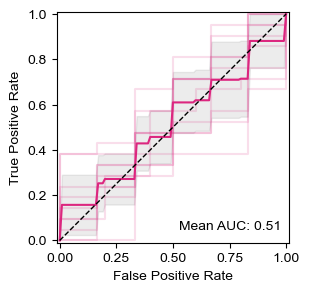

In [12]:
evaluate_model(cv, mlp, X, y_scrambled, plot_path='plots/mlp_hem_scrambled.png', color='#DC267F')

True labels

Mean accuracy: 0.9 ± 0.04
Mean precision: 0.93 ± 0.02
Mean recall: 0.94 ± 0.05
Mean F1: 0.93 ± 0.02


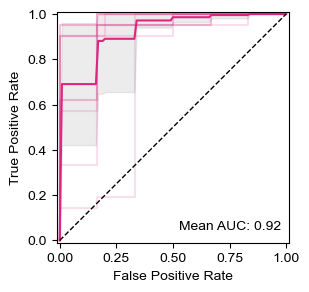

In [13]:
evaluate_model(cv, mlp, X, y, plot_path='plots/mlp_hem_true.png', color='#DC267F')

Train model on full dataset and store it

In [14]:
mlp_hem = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
mlp_hem.fit(X, y)

joblib.dump(mlp_hem, 'models/mlp_hem.joblib')

['models/mlp_hem.joblib']

#### Select Validation Round

Load models

In [15]:
mlp_act = joblib.load('models/mlp_act.joblib')
mlp_hem = joblib.load('models/mlp_hem.joblib')

Enumerate ln65 diastereomers

In [16]:
ln65 = 'KKLLKLLKLLL'

combinations = list(product(*[(c.upper(), c.lower()) for c in ln65]))
ln65_diastereomers = [''.join(c) for c in combinations]
ln65_encoded = np.array([seq_fingerprint(c) for c in ln65_diastereomers])

act_pred = mlp_act.predict(ln65_encoded)
hem_pred = mlp_hem.predict(ln65_encoded)

df_pred = pd.DataFrame({'sequence': ln65_diastereomers, 'active': act_pred, 'not hemolytic': hem_pred})

Remove sequences that were already tested

In [17]:
synthesized_sequences = synthesized['sequence'].tolist()
df_pred = df_pred[~df_pred['sequence'].isin(synthesized_sequences)].reset_index(inplace=False, drop=True)

Add set names

In [18]:
def set_name(row):
    if row['active'] == 1 and row['not hemolytic'] == 1:
        return 'active and not hemolytic'
    elif row['active'] == 1 and row['not hemolytic'] == 0:
        return 'active and hemolytic'
    elif row['active'] == 0 and row['not hemolytic'] == 1:
        return 'inactive and not hemolytic'
    elif row['active'] == 0 and row['not hemolytic'] == 0:
        return 'inactive and hemolytic'

df_pred['set'] = df_pred.apply(set_name, axis=1)

Export sets

In [19]:
df_pred[df_pred['set'] == 'active and not hemolytic'].to_csv('data/validation_sets/active_not_hemolytic.csv', index=False)
df_pred[df_pred['set'] == 'active and hemolytic'].to_csv('data/validation_sets/active_hemolytic.csv', index=False)
df_pred[df_pred['set'] == 'inactive and not hemolytic'].to_csv('data/validation_sets/inactive_not_hemolytic.csv', index=False)
df_pred[df_pred['set'] == 'inactive and hemolytic'].to_csv('data/validation_sets/inactive_hemolytic.csv', index=False)

##  OOF prediction probability histograms

P(active) and P(hemolytic) for the initial-model diastereomers, comparing true vs scrambled labels. Probabilities are out-of-fold predictions from the 10-fold cross-validation.

In [20]:
from matplotlib.patches import Patch

def oof_probabilities(X, y):
    """Out-of-fold P(class 1) from 10-fold StratifiedKFold, refit per fold."""
    mlp = MLPClassifier(alpha=1, max_iter=1000,
                        hidden_layer_sizes=(32, 32, 32), random_state=42)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    oof = np.full(len(y), np.nan)
    for train, test in cv.split(X, y):
        mlp.fit(X[train], y[train])
        oof[test] = mlp.predict_proba(X[test])[:, 1]
    return oof

In [21]:
df = pd.read_csv("data/synthesized.csv")
X = np.array([seq_fingerprint(s) for s in df["sequence"]])

# Activity: true and scrambled labels
seed(42)
y_act = df["active"].to_numpy()
y_act_scr = np.array(sample(list(y_act), len(y_act)))
prob_act_true = oof_probabilities(X, y_act)
prob_act_scr = oof_probabilities(X, y_act_scr)

# Hemolysis: train on native 'not hemolytic' target, then display P(hemolytic)
seed(42)
y_nothem = df["not hemolytic"].to_numpy()
y_nothem_scr = np.array(sample(list(y_nothem), len(y_nothem)))
y_hem = 1 - y_nothem                                  # 1 = hemolytic
y_hem_scr = 1 - y_nothem_scr
prob_hem_true = 1 - oof_probabilities(X, y_nothem)    # P(hemolytic)
prob_hem_scr = 1 - oof_probabilities(X, y_nothem_scr)

auc_act_true = roc_auc_score(y_act, prob_act_true)
auc_hem_true = roc_auc_score(y_hem, prob_hem_true)
auc_act_scr = 0.58
auc_hem_scr = 0.54
print(f"AUC activity  true / scrambled: {auc_act_true:.2f} / {auc_act_scr:.2f}")
print(f"AUC hemolysis true / scrambled: {auc_hem_true:.2f} / {auc_hem_scr:.2f}")

AUC activity  true / scrambled: 0.90 / 0.58
AUC hemolysis true / scrambled: 0.92 / 0.54


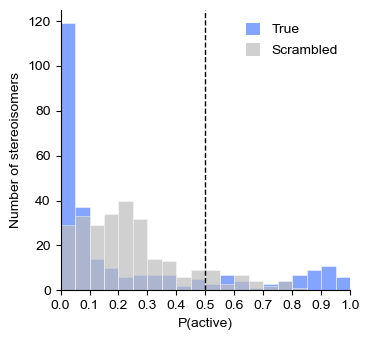

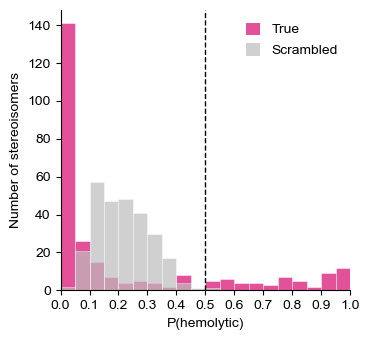

In [22]:
bins = np.linspace(0, 1, 21)
scr_color = "#bdbdbd"

def make_figure(prob_true, prob_scr, color, auc_true, auc_scr, xlabel, outfile):
    fig, ax = plt.subplots(figsize=(3.8, 3.5))
    ax.hist(prob_true, bins=bins, color=color, alpha=0.8,
            edgecolor="white", linewidth=0.4)
    ax.hist(prob_scr, bins=bins, color=scr_color, alpha=0.7,
            edgecolor="white", linewidth=0.4)
    ax.axvline(0.5, color="k", ls="--", lw=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of stereoisomers")
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0.0, 1.01, 0.1))
    handles = [
        Patch(facecolor=color,     alpha=0.8, label="True"),
        Patch(facecolor=scr_color, alpha=0.7, label="Scrambled"),
    ]
    ax.legend(handles=handles, frameon=False, fontsize=10, loc="upper right",
              handlelength=1.0, handleheight=1.0)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(outfile, dpi=1200, bbox_inches="tight")
    return fig

# P(active)
make_figure(prob_act_true, prob_act_scr, "#648FFF",
            auc_act_true, auc_act_scr, "P(active)",
            "plots/prob_hist_activity.png")

# P(hemolytic)
make_figure(prob_hem_true, prob_hem_scr, "#DC267F",
            auc_hem_true, auc_hem_scr, "P(hemolytic)",
            "plots/prob_hist_hemolysis.png")

plt.show()

## Full model

Same training and 10-fold cross-validation as the initial model above, on the deduplicated 321-sequence experimental set (`synthesized_full-deduplicated.csv`). No prospective-round generation.

#### Import dataset

In [23]:
synthesized_full = pd.read_csv('data/synthesized_full-deduplicated.csv')
synthesized_full['fingerprint'] = synthesized_full['sequence'].apply(seq_fingerprint)

#### Data Preprocessing: Activity

In [24]:
seed(42)

X = np.array(synthesized_full['fingerprint'].tolist())
y = np.array(synthesized_full['active'].tolist())
y_scrambled = np.array(sample(list(y), len(y)))

#### Model Validation: Activity

In [25]:
mlp = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Scrambled labels

Mean accuracy: 0.59 ± 0.08
Mean precision: 0.41 ± 0.17
Mean recall: 0.37 ± 0.1
Mean F1: 0.37 ± 0.08


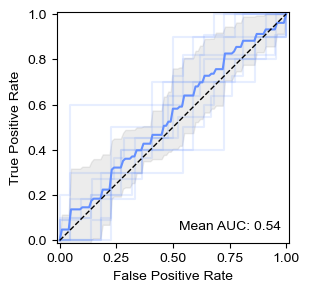

In [26]:
evaluate_model(cv, mlp, X, y_scrambled, plot_path='plots/full_mlp_act_scrambled.png')

True labels

Mean accuracy: 0.88 ± 0.04
Mean precision: 0.84 ± 0.12
Mean recall: 0.8 ± 0.09
Mean F1: 0.81 ± 0.06


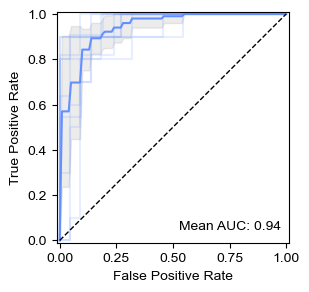

In [27]:
evaluate_model(cv, mlp, X, y, plot_path='plots/full_mlp_act_true.png')

Train model on full dataset and store it

In [28]:
full_model_mlp_act = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
full_model_mlp_act.fit(X, y)

joblib.dump(full_model_mlp_act, 'models/full_model_mlp_act.joblib')

['models/full_model_mlp_act.joblib']

#### Data Preprocessing: Hemolysis

In [29]:
seed(42)

X = np.array(synthesized_full['fingerprint'].tolist())
y = np.array(synthesized_full['not hemolytic'].tolist())
y_scrambled = np.array(sample(list(y), len(y)))

#### Model Validation: Hemolysis

In [30]:
mlp = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Scrambled labels

Mean accuracy: 0.62 ± 0.04
Mean precision: 0.73 ± 0.04
Mean recall: 0.75 ± 0.08
Mean F1: 0.74 ± 0.04


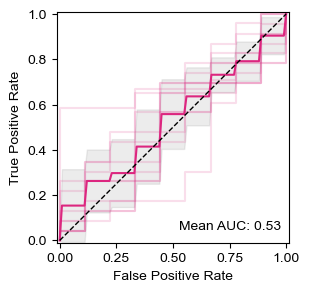

In [31]:
evaluate_model(cv, mlp, X, y_scrambled, plot_path='plots/full_mlp_hem_scrambled.png', color='#DC267F')

True labels

Mean accuracy: 0.92 ± 0.03
Mean precision: 0.94 ± 0.03
Mean recall: 0.95 ± 0.06
Mean F1: 0.94 ± 0.03


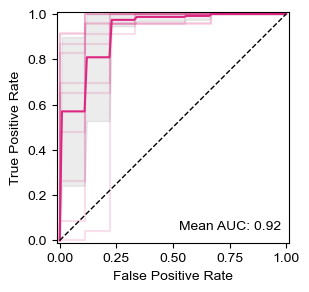

In [32]:
evaluate_model(cv, mlp, X, y, plot_path='plots/full_mlp_hem_true.png', color='#DC267F')

Train model on full dataset and store it

In [33]:
full_model_mlp_hem = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
full_model_mlp_hem.fit(X, y)

joblib.dump(full_model_mlp_hem, 'models/full_model_mlp_hem.joblib')

['models/full_model_mlp_hem.joblib']

## Augmented model 

The experimental 321-sequence set is augmented with the missing mirror-image enantiomer of each measured stereoisomer (each enantiomer inherits the same activity/hemolysis labels), giving 310 complete pairs (620 sequences). Cross-validation uses `StratifiedGroupKFold` with each enantiomer pair assigned to one group, so a sequence and its mirror image are never split across training and test folds (which would leak information).

#### Import dataset

In [34]:
augmented = pd.read_csv('data/augmented_deduplicated.csv')
augmented['fingerprint'] = augmented['sequence'].apply(seq_fingerprint)

#### Mirror-aware groups

Each sequence and its mirror image share the same group key, keeping the 310 pairs together during cross-validation.

In [35]:
def mirror(sequence):
    return sequence.swapcase()

# each enantiomer pair shares a group -> mirror images stay in the same CV fold
groups = np.array([min(s, mirror(s)) for s in augmented['sequence']])

Group-aware evaluation helper (identical to `evaluate_model`, but the fold split is grouped by enantiomer pair)

In [36]:
def evaluate_model_grouped(cv, mlp, X, y, groups, plot_path='plots/model_eval.png', color='#648FFF'):

    aucs = []
    tprs = []
    base_fpr = np.linspace(0, 1, 101)

    accuracies = []
    precisions = []
    recalls = []
    f1s = []

    plt.figure(figsize=(3, 3))
    plt.axes().set_aspect('equal', 'datalim')

    for i, (train, test) in enumerate(cv.split(X, y, groups)):
        mlp.fit(X[train], y[train])

        y_score = mlp.predict_proba(X[test])
        y_pred = mlp.predict(X[test])

        fpr, tpr, _ = roc_curve(y[test], y_score[:, 1])
        accuracies.append(accuracy_score(y[test], y_pred))
        precisions.append(precision_score(y[test], y_pred, zero_division=0))
        recalls.append(recall_score(y[test], y_pred, zero_division=0))
        f1s.append(f1_score(y[test], y_pred, zero_division=0))

        plt.plot(fpr, tpr, color, alpha=0.15)

        tpr = np.interp(base_fpr, fpr, tpr)
        tpr[0] = 0.0

        tprs.append(tpr)
        aucs.append(roc_auc_score(y[test], y_score[:, 1]))

    tprs = np.array(tprs)
    mean_tprs = tprs.mean(axis=0)
    std = tprs.std(axis=0)
    tprs_upper = np.minimum(mean_tprs + std, 1)
    tprs_lower = mean_tprs - std

    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    mean_precision = np.mean(precisions)
    std_precision = np.std(precisions)

    mean_recall = np.mean(recalls)
    std_recall = np.std(recalls)

    mean_f1 = np.mean(f1s)
    std_f1 = np.std(f1s)

    plt.plot(base_fpr, mean_tprs, color)
    plt.fill_between(base_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.15)

    plt.plot([0, 1], [0, 1],'k--', linewidth=1)
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.text(0.525, 0.05, f'Mean AUC: {round(np.mean(aucs), 2)}')
    plt.savefig(plot_path, dpi=1200, bbox_inches='tight')

    print(f'Mean accuracy: {round(mean_accuracy, 2)} ± {round(std_accuracy, 2)}')
    print(f'Mean precision: {round(mean_precision, 2)} ± {round(std_precision, 2)}')
    print(f'Mean recall: {round(mean_recall, 2)} ± {round(std_recall, 2)}')
    print(f'Mean F1: {round(mean_f1, 2)} ± {round(std_f1, 2)}')

#### Data Preprocessing: Activity

In [37]:
seed(42)

X = np.array(augmented['fingerprint'].tolist())
y = np.array(augmented['active'].tolist())
y_scrambled = np.array(sample(list(y), len(y)))

#### Model Validation: Activity

In [38]:
from sklearn.model_selection import StratifiedGroupKFold

mlp = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

Scrambled labels

Mean accuracy: 0.57 ± 0.08
Mean precision: 0.24 ± 0.14
Mean recall: 0.15 ± 0.08
Mean F1: 0.18 ± 0.09


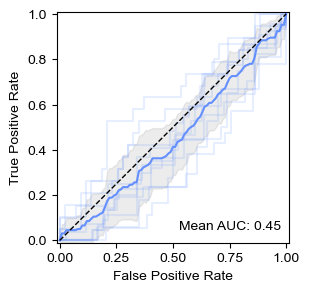

In [39]:
evaluate_model_grouped(cv, mlp, X, y_scrambled, groups, plot_path='plots/aug_mlp_act_scrambled.png')

True labels

Mean accuracy: 0.9 ± 0.06
Mean precision: 0.86 ± 0.08
Mean recall: 0.82 ± 0.11
Mean F1: 0.84 ± 0.08


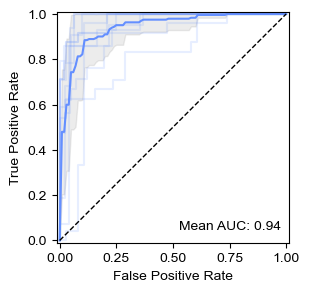

In [40]:
evaluate_model_grouped(cv, mlp, X, y, groups, plot_path='plots/aug_mlp_act_true.png')

Train model on full dataset and store it

In [41]:
augmented_model_mlp_act = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
augmented_model_mlp_act.fit(X, y)

joblib.dump(augmented_model_mlp_act, 'models/augmented_model_mlp_act.joblib')

['models/augmented_model_mlp_act.joblib']

#### Data Preprocessing: Hemolysis

In [42]:
seed(42)

X = np.array(augmented['fingerprint'].tolist())
y = np.array(augmented['not hemolytic'].tolist())
y_scrambled = np.array(sample(list(y), len(y)))

#### Model Validation: Hemolysis

In [43]:
from sklearn.model_selection import StratifiedGroupKFold

mlp = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

Scrambled labels

Mean accuracy: 0.63 ± 0.06
Mean precision: 0.73 ± 0.07
Mean recall: 0.79 ± 0.08
Mean F1: 0.75 ± 0.05


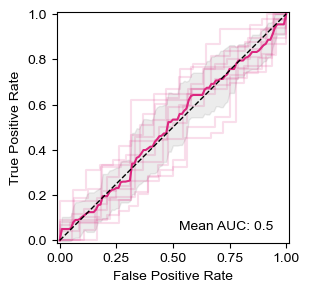

In [44]:
evaluate_model_grouped(cv, mlp, X, y_scrambled, groups, plot_path='plots/aug_mlp_hem_scrambled.png', color='#DC267F')

True labels

Mean accuracy: 0.89 ± 0.05
Mean precision: 0.91 ± 0.06
Mean recall: 0.95 ± 0.04
Mean F1: 0.93 ± 0.03


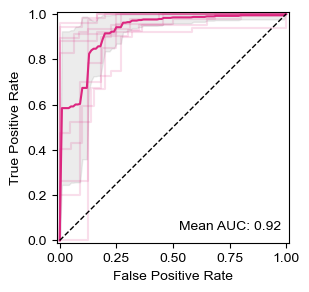

In [45]:
evaluate_model_grouped(cv, mlp, X, y, groups, plot_path='plots/aug_mlp_hem_true.png', color='#DC267F')

Train model on full dataset and store it

In [46]:
augmented_model_mlp_hem = MLPClassifier(alpha=1, max_iter=1000, hidden_layer_sizes=(32, 32, 32), random_state=42)
augmented_model_mlp_hem.fit(X, y)

joblib.dump(augmented_model_mlp_hem, 'models/augmented_model_mlp_hem.joblib')

['models/augmented_model_mlp_hem.joblib']